In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#!pip install torchvision
import torch



In [2]:
# Load the dataset
data = pd.read_csv('league_of_legends_data_large.csv')
data.describe()

,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.51000,9.332000,9.487000,9.395000,12433.808000,181.21300,9.834000,4.541000,27484.905000
std,0.50015,5.798569,5.773488,5.765086,4388.138751,72.11491,5.739633,2.906332,13221.571932
min,0.00000,0.000000,0.000000,0.000000,5002.000000,50.00000,0.000000,0.000000,5028.000000
25%,0.00000,4.000000,4.000000,4.000000,8551.750000,121.00000,5.000000,2.000000,15759.000000
50%,1.00000,9.000000,9.000000,10.000000,12295.000000,183.50000,10.000000,5.000000,27370.000000
75%,1.00000,14.000000,14.000000,14.000000,16348.250000,243.00000,15.000000,7.000000,39453.000000
max,1.00000,19.000000,19.000000,19.000000,19955.000000,299.00000,19.000000,9.000000,49927.000000


In [3]:
# Preprocess the data
X = data.drop('win', axis=1)
y = data['win']
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
print("Data loading, splitting, and standardization complete.")

Data loading, splitting, and standardization complete.


In [4]:
import torch.nn as nn
import torch.optim as optim

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Initialize the model, loss function, and optimizer
input_dim = X_train.shape[1]
model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print("Model, loss function, and optimizer initialization complete.")

Model, loss function, and optimizer initialization complete.


In [5]:
# Training the model
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [100/1000], Loss: 0.7218
Epoch [200/1000], Loss: 0.7085
Epoch [300/1000], Loss: 0.6999
Epoch [400/1000], Loss: 0.6944
Epoch [500/1000], Loss: 0.6910
Epoch [600/1000], Loss: 0.6888
Epoch [700/1000], Loss: 0.6875
Epoch [800/1000], Loss: 0.6867
Epoch [900/1000], Loss: 0.6861
Epoch [1000/1000], Loss: 0.6858


In [6]:
# Model evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train).detach()
    y_pred_test = model(X_test).detach()
    
train_accuracy = ((y_pred_train > 0.5) == y_train).float().mean()
test_accuracy = ((y_pred_test > 0.5) == y_test).float().mean()

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Train Accuracy: 0.5450
Test Accuracy: 0.4900


In [7]:
# Implementing L2 regularization (Ridge Regression)
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)

# Retrain the model with L2 regularization
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.6856
Epoch [200/1000], Loss: 0.6855
Epoch [300/1000], Loss: 0.6854
Epoch [400/1000], Loss: 0.6853
Epoch [500/1000], Loss: 0.6853
Epoch [600/1000], Loss: 0.6853
Epoch [700/1000], Loss: 0.6853
Epoch [800/1000], Loss: 0.6853
Epoch [900/1000], Loss: 0.6853
Epoch [1000/1000], Loss: 0.6853


In [8]:
# Evaluate the optimized model
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train).detach()
    y_pred_test = model(X_test).detach()
    
train_accuracy = ((y_pred_train > 0.5) == y_train).float().mean()
test_accuracy = ((y_pred_test > 0.5) == y_test).float().mean()

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


Train Accuracy: 0.5462
Test Accuracy: 0.5000


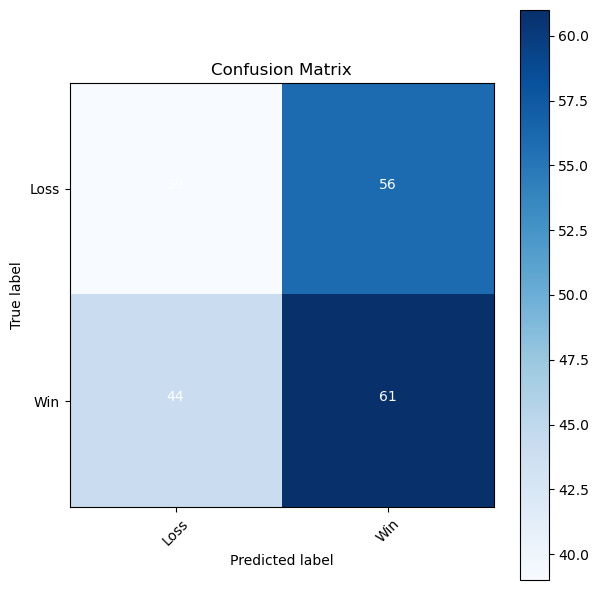

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools

# Visualize the confusion matrix
y_pred_test_labels = (y_pred_test > 0.5).float()
cm = confusion_matrix(y_test, y_pred_test_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [10]:
# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_test_labels, target_names=['Loss', 'Win']))

Classification Report:
               precision    recall  f1-score   support

        Loss       0.47      0.41      0.44        95
         Win       0.52      0.58      0.55       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.50      0.50       200



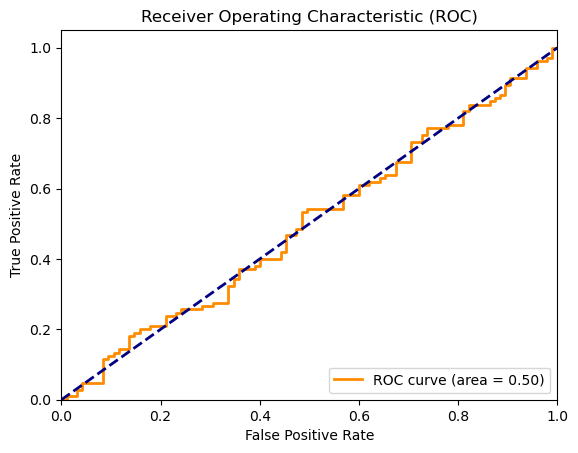

In [11]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [12]:
# Save the model
torch.save(model.state_dict(), 'logistic_regression_model.pth')

# Load the model
loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load('logistic_regression_model.pth'))

# Ensure the loaded model is in evaluation mode
loaded_model.eval()

LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [13]:
# Evaluate the loaded model
with torch.no_grad():
    y_pred_test_loaded = loaded_model(X_test).detach()
    loaded_test_accuracy = ((y_pred_test_loaded > 0.5) == y_test).float().mean()
    print(f'Loaded Model Test Accuracy: {loaded_test_accuracy:.4f}')

learning_rates = [0.01, 0.05, 0.1]
best_accuracy = 0
best_lr = 0

for lr in learning_rates:
    # Reinitialize the model and optimizer for each learning rate
    model = LogisticRegressionModel(input_dim)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Training the model
    epochs = 1000
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        if (epoch+1) % 100 == 0:
            print(f'Learning Rate: {lr}, Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    # Evaluate the model
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test).detach()
        test_accuracy = ((y_pred_test > 0.5) == y_test).float().mean()
        print(f'Learning Rate: {lr}, Test Accuracy: {test_accuracy:.4f}')
        
        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_lr = lr

print(f'Best Learning Rate: {best_lr}, Best Test Accuracy: {best_accuracy:.4f}')



Loaded Model Test Accuracy: 0.5000
Learning Rate: 0.01, Epoch [100/1000], Loss: 0.7188
Learning Rate: 0.01, Epoch [200/1000], Loss: 0.7059
Learning Rate: 0.01, Epoch [300/1000], Loss: 0.6979
Learning Rate: 0.01, Epoch [400/1000], Loss: 0.6930
Learning Rate: 0.01, Epoch [500/1000], Loss: 0.6900
Learning Rate: 0.01, Epoch [600/1000], Loss: 0.6882
Learning Rate: 0.01, Epoch [700/1000], Loss: 0.6871
Learning Rate: 0.01, Epoch [800/1000], Loss: 0.6864
Learning Rate: 0.01, Epoch [900/1000], Loss: 0.6859
Learning Rate: 0.01, Epoch [1000/1000], Loss: 0.6857
Learning Rate: 0.01, Test Accuracy: 0.5350
Learning Rate: 0.05, Epoch [100/1000], Loss: 0.6875
Learning Rate: 0.05, Epoch [200/1000], Loss: 0.6854
Learning Rate: 0.05, Epoch [300/1000], Loss: 0.6853
Learning Rate: 0.05, Epoch [400/1000], Loss: 0.6853
Learning Rate: 0.05, Epoch [500/1000], Loss: 0.6852
Learning Rate: 0.05, Epoch [600/1000], Loss: 0.6852
Learning Rate: 0.05, Epoch [700/1000], Loss: 0.6852
Learning Rate: 0.05, Epoch [800/1000]